In [1]:
import pandas as pd
import numpy as np

# Reading the data into a dataframe

df = pd.read_csv("SBAnational.csv", header= 0)

C:\Users\cnrzh\AppData\Local\Temp\ipykernel_36640\4277921081.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("SBAnational.csv", header= 0)


In [2]:
#Begin Exploratory Data analysis and Feature Engineering
print(f"Dataset Shape: {df.shape}")
print()
print(df.info())
print()
print(df.describe())
print()
print("Null values per column:\n", df.isna().sum())
print()
print("Number of duplicates:", df.duplicated().sum())

Dataset Shape: (899164, 27)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  object 
 2   City               899134 non-null  object 
 3   State              899150 non-null  object 
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  object 
 6   BankState          897598 non-null  object 
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  object 
 9   ApprovalFY         899164 non-null  object 
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899

In [3]:
#Handle missing values

#Some columns have so few missing values that we can drop the missing rows,
#without having a big impact on the dataset
df = df.dropna(subset = ["Name", 'City', "State", "MIS_Status"])

print(df["MIS_Status"].isna().sum())
#Other columns will have a "U" value added for unknown
df["Bank"].fillna("U", inplace=True)
df["BankState"].fillna("U", inplace=True)
df["RevLineCr"].fillna("U", inplace=True)
df["LowDoc"].fillna("U", inplace=True)

#Most rows in the columns have a null value for CHGOffDat. This is expected,
#as the value is only filled in for loans that have defaulted. Currently,
#we don't plan to use this column for our models, so we can leave it alone
#for now.

0


C:\Users\cnrzh\AppData\Local\Temp\ipykernel_36640\2961018742.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Bank"].fillna("U", inplace=True)
C:\Users\cnrzh\AppData\Local\Temp\ipykernel_36640\2961018742.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

In [4]:
#Pandas rasied a flag saying that column "ApprovalFY" has rows with different types.
print("Unique values for column ApprovalFY:", df["ApprovalFY"].unique())
#There are samples that store the year as a string instead of an int, and an outlier has the value "1976A"
#We will trim the letter A from the outlier, and convert all rows of this column to integers.
df["ApprovalFY"] = df["ApprovalFY"].astype(str).replace("1976A", "1976").astype(int)
print("Unique values for column ApprovalFY:", df["ApprovalFY"].unique())
print()

#For column FranchiseCode, both 00000 00001 signify no franchise, so we will condense them to 00000
df.loc[df["FranchiseCode"] == 1, "FranchiseCode"] = 0
print("Unique values for LowDoc", df["LowDoc"].unique())
#Column LowDoc is supposed to be simple binary values of "yes" or "no", but the list of values that occur
#is "Y", "N", "C", "1", "nan", "S", "R", "A", "0".
#There are approximately 4500 rows that contain values S, R, A, C, or nan
#For now, we will convert "1" to "Y", "0" to "N", and mark the other values
#as U for undefined
df.loc[df["LowDoc"] == "1", "LowDoc"] = "Y"
df.loc[df["LowDoc"] == "0", "LowDoc"] = "N"
df.loc[(df["LowDoc"] != "Y") & (df["LowDoc"] != "N"), "LowDoc"] = "U"
print("Unique values for LowDoc", df["LowDoc"].unique())
print()

print("Unique values in column NewExist", df["NewExist"].unique())
#Per the documentation, the column NewExist should store values
#{1 : Existing Business, 2: New Business}, but this column also contains
#missing values and 0 values.
#We are converted these values to "E", "N", and "U". This way they can later 
#be scaled with one hot encoding
df.loc[df["NewExist"] == 1.0, "NewExist"] = "E"
df.loc[df["NewExist"] == 2.0, "NewExist"] = "N"
df.loc[(df["NewExist"].isna()) | (df["NewExist"] == 0.0), "NewExist"] = "U"
print("Unique values in column NewExist", df["NewExist"].unique())
print()

print("Unique Values of RevLineCr", df["RevLineCr"].unique())
#This column should just be Y or N. We will map the values to Y, N and U for 
#undefined. Later than can be encoded with one hot encoding
df.loc[(df["RevLineCr"] != "Y") & (df["RevLineCr"] != "N"), "RevLineCr"] = "U"
print("Unique Values of RevLineCr", df["RevLineCr"].unique())

#Convert monetary columns DisbursementGross, BalanceGross, ChgOffPrinGr, 
#GrAppv and SBA_Appv from strings to floats
df["DisbursementGross"] = (
    df["DisbursementGross"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)
df["BalanceGross"] = (
    df["BalanceGross"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)
df["ChgOffPrinGr"] = (
    df["ChgOffPrinGr"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)
df["GrAppv"] = (
    df["GrAppv"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)
df["SBA_Appv"] = (
    df["SBA_Appv"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)

#There are samples that have values for State or BankState that are not one of the 50 states. These
#could represent US territories or clerical errors. They make up a small amount of the data set,
#so we will drop them.
states = [    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"]

print(df[~df["State"].isin(states)]["State"].count())
print(df[~df["BankState"].isin(states)]["BankState"].count())
df = df[(df["State"].isin(states)) & (df["BankState"].isin(states))]
print(df[~df["State"].isin(states)]["State"].count())
print(df[~df["BankState"].isin(states)]["BankState"].count())

Unique values for column ApprovalFY: [1997 1980 2006 1998 1999 2000 2001 1972 2003 2004 1978 1979 1981 2005
 1982 1983 1973 1984 2007 1985 1986 1987 2008 1988 2009 1989 1991 1990
 1974 2010 2011 1992 1993 2002 2012 2013 1994 2014 1975 1977 1976 '2004'
 '1994' '1979' '1976' '1975' '1974' '1977' '1981' '1982' '1983' '1984'
 '1978' '1980' '1968' '1976A' '1969' '1995' '1970' '2005' '1996' '1971'
 1996 1971]
Unique values for column ApprovalFY: [1997 1980 2006 1998 1999 2000 2001 1972 2003 2004 1978 1979 1981 2005
 1982 1983 1973 1984 2007 1985 1986 1987 2008 1988 2009 1989 1991 1990
 1974 2010 2011 1992 1993 2002 2012 2013 1994 2014 1975 1977 1976 1968
 1969 1995 1970 1996 1971]

Unique values for LowDoc ['Y' 'N' 'C' '1' 'U' 'S' 'R' 'A' '0']
Unique values for LowDoc ['Y' 'N' 'U']

Unique values in column NewExist [ 2.  1.  0. nan]


C:\Users\cnrzh\AppData\Local\Temp\ipykernel_36640\3832883277.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'E' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["NewExist"] == 1.0, "NewExist"] = "E"


Unique values in column NewExist ['N' 'E' 'U']

Unique Values of RevLineCr ['N' '0' 'Y' 'T' 'U' '`' ',' '1' 'C' '3' '2' 'R' '7' 'A' '5' '.' '4' '-'
 'Q']
Unique Values of RevLineCr ['N' 'U' 'Y']
1613
5677
0
0


In [5]:
df["ApprovalDate"] = pd.to_datetime(df["ApprovalDate"], errors="coerce")

df = df[
    (df["ApprovalDate"] >= "2007-01-01") &
    (df["ApprovalDate"] <= "2012-12-31")
].copy()

df["Zip"] = df["Zip"].astype(str).str.zfill(5)

C:\Users\cnrzh\AppData\Local\Temp\ipykernel_36640\3678098009.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ApprovalDate"] = pd.to_datetime(df["ApprovalDate"], errors="coerce")


In [6]:
#There are some additional features that can be extracted from this data set.

#ChgOffPinGr represents the gross amount of principal that was left on the
#loan after the lender placed it in default. SBA_Appv, is the amount that 
#the SBA guarantees in case of default. We can use these two  features to 
#calculate how much the SBA needed to reimburse the lender for each default.
df["SBA_payout"] = np.minimum(df["SBA_Appv"], df["ChgOffPrinGr"])

#The first two digits of the NAICS code indicate its industry. We will use
#this to create an Industry categorical variable.
exact_mapping = {
    11: "Agriculture, forestry, fishing and hunting",
    21: "Mining, quarrying, and oil and gas extraction",
    22: "Utilities",
    23: "Construction",
    42: "Wholesale trade",
    51: "Information",
    52: "Finance and insurance",
    53: "Real estate and rental and leasing",
    54: "Professional, scientific, and technical services",
    55: "Management of companies and enterprises",
    56: "Administrative and support and waste management and remediation services",
    61: "Educational services",
    62: "Health care and social assistance",
    71: "Arts, entertainment, and recreation",
    72: "Accommodation and food services",
    81: "Other services (except public administration)",
    92: "Public administration"
}
def map_naics(code):
    code = int(str(code)[:2])
    if 31 <= code <= 33:
        return "Manufacturing"
    elif 44 <= code <= 45:
        return "Retail trade"
    elif 48 <= code <= 49:
        return "Transportation and warehousing"
    else:
        return exact_mapping.get(code, "Unknown")
df["Industry"] = df["NAICS"].apply(map_naics)
print(df["Industry"].unique())

#Some features are unique identifiers that we don't expect to have a
#correlation with our targets. We will drop these.
#We will also drop ChgOffDate due to the high number of missing values
#and we will drop DisbursementDate and ApprovalDate, as ApprovalFY
#gives us all the time information that we need.
df = df.drop(columns = ["LoanNr_ChkDgt", "Name", "Bank", "ApprovalDate",
                       "DisbursementDate"])

['Retail trade' 'Construction' 'Finance and insurance'
 'Real estate and rental and leasing'
 'Other services (except public administration)'
 'Professional, scientific, and technical services'
 'Transportation and warehousing' 'Accommodation and food services'
 'Manufacturing'
 'Administrative and support and waste management and remediation services'
 'Wholesale trade' 'Health care and social assistance'
 'Educational services' 'Information'
 'Arts, entertainment, and recreation'
 'Agriculture, forestry, fishing and hunting'
 'Mining, quarrying, and oil and gas extraction' 'Public administration'
 'Utilities' 'Management of companies and enterprises' 'Unknown']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148347 entries, 166957 to 896097
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   City               148347 non-null  object 
 1   State              148347 non-null  object 
 2   Zip                148347 non-null  object 
 3   BankState          148347 non-null  object 
 4   NAICS              148347 non-null  int64  
 5   ApprovalFY         148347 non-null  int64  
 6   Term               148347 non-null  int64  
 7   NoEmp              148347 non-null  int64  
 8   NewExist           148347 non-null  object 
 9   CreateJob          148347 non-null  int64  
 10  RetainedJob        148347 non-null  int64  
 11  FranchiseCode      148347 non-null  int64  
 12  UrbanRural         148347 non-null  int64  
 13  RevLineCr          148347 non-null  object 
 14  LowDoc             148347 non-null  object 
 15  ChgOffDate         48418 non-null   object 
 16  Di

In [8]:
print("Count of PIF samples: ", df[df["MIS_Status"] == "P I F"]["MIS_Status"].count())
print("Count of CHGOFF samples: ", df[df["MIS_Status"] == "CHGOFF"]["MIS_Status"].count())

Count of PIF samples:  101055
Count of CHGOFF samples:  47292


In [9]:
df.head()

,City,State,Zip,BankState,NAICS,ApprovalFY,Term,NoEmp,NewExist,CreateJob,...,LowDoc,ChgOffDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,SBA_payout,Industry
166957,Niagara Falls,NY,14303,NY,445110,2007,84,5,E,0,...,N,NaN,200000.0,0.0,P I F,0.0,200000.0,100000.0,0.0,Retail trade
166959,ORANGE,CA,92869,VA,238330,2007,57,2,E,2,...,N,6-Feb-10,166902.0,0.0,CHGOFF,48984.0,50000.0,25000.0,25000.0,Construction
166962,MIDLOTHIAN,VA,23113,VA,524128,2007,34,2,E,1,...,N,14-Jul-11,119054.0,0.0,CHGOFF,48454.0,50000.0,25000.0,25000.0,Finance and insurance
166964,HAZELWOOD,MO,63042,VA,531210,2007,39,1,E,2,...,N,14-Jan-11,84399.0,0.0,CHGOFF,28863.0,35000.0,17500.0,17500.0,Real estate and rental and leasing
166966,HIALEAH,FL,33010,NC,811111,2007,46,3,N,0,...,N,5-May-10,12169.0,0.0,CHGOFF,4778.0,5000.0,2500.0,2500.0,Other services (except public administration)


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#Prepare for Decision Tree Classifier.
categoricalFeatures = ["State", "BankState", "Industry", "NewExist",
                      "UrbanRural", "RevLineCr", "LowDoc"]
desiredFeatures = ["Term", "NoEmp", "CreateJob", "RetainedJob", 
                   "DisbursementGross", "GrAppv", "SBA_Appv", "ApprovalFY",
              "State", "BankState", "Industry", "NewExist",
                 "FranchiseCode", "UrbanRural", "RevLineCr", "LowDoc"]
X_tree = df[desiredFeatures]
Y_tree = df["MIS_Status"]
#Stratify during splits to make up for class imbalance
x_tree_train, x_tree_testVal, y_tree_train, y_tree_testVal =\
    train_test_split(X_tree, Y_tree, test_size = 0.3, random_state = 42,\
                    stratify = Y_tree)
x_tree_val, x_tree_test, y_tree_val, y_tree_test =\
    train_test_split(x_tree_testVal, y_tree_testVal, test_size = 0.5,\
                     random_state = 42, stratify = y_tree_testVal)

encoders = {}
for col in categoricalFeatures:
    le = LabelEncoder()
    x_tree_train[col] = le.fit_transform(x_tree_train[col])
    encoders[col] = le
for col in categoricalFeatures:
    le = encoders[col]
    x_tree_val[col] = le.transform(x_tree_val[col])
    x_tree_test[col] = le.transform(x_tree_test[col])

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#First we experiement with different max depths
for i in range(1, 19):
    treeModel = DecisionTreeClassifier(criterion = "entropy", max_depth = i, random_state = 42)
    treeModel.fit(x_tree_train, y_tree_train)
    
    y_train_pred = treeModel.predict(x_tree_train)
    y_val_pred = treeModel.predict(x_tree_val)

    train_acc = accuracy_score(y_tree_train, y_train_pred)
    val_acc = accuracy_score(y_tree_val, y_val_pred)
    print("Entropy impurity with %d max depth:\n"%(i))
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print()
    cm = confusion_matrix(y_tree_val, y_val_pred)
    report = classification_report(y_tree_val, y_val_pred, zero_division=0)
    print(cm)
    print()
    print(report)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#We see the decision tree struggles to correctly predict default loans
#Precision and Recall scores for default loans level  off around a depth
#of 9. However, such a high depth brings a high risk of variance. We will now
#run the model with different values min_sample_leaf to test the benefits of 
#prepruning.
treeModel = DecisionTreeClassifier(criterion = "gini", max_depth = 9,\
                                   random_state = 42)
treeModel.fit(x_tree_train, y_tree_train)

y_train_pred = treeModel.predict(x_tree_train)
y_val_pred = treeModel.predict(x_tree_val)

train_acc = accuracy_score(y_tree_train, y_train_pred)
val_acc = accuracy_score(y_tree_val, y_val_pred)
print("Gini impurity:\n")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print()
cm = confusion_matrix(y_tree_val, y_val_pred)
report = classification_report(y_tree_val, y_val_pred, zero_division=0)
print(cm)
print()
print(report)

#First we experiement with different max depths
for i in [1, 10, 25, 50, 100, 250, 500, 1000, 2500]:
    treeModel = DecisionTreeClassifier(criterion = "entropy", max_depth = 9,\
                                       min_samples_leaf = i, random_state = 42)
    treeModel.fit(x_tree_train, y_tree_train)
    
    y_train_pred = treeModel.predict(x_tree_train)
    y_val_pred = treeModel.predict(x_tree_val)

    train_acc = accuracy_score(y_tree_train, y_train_pred)
    val_acc = accuracy_score(y_tree_val, y_val_pred)
    print("Entropy impurity with %d min_samples_leaf:\n"%(i))
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print()
    cm = confusion_matrix(y_tree_val, y_val_pred)
    report = classification_report(y_tree_val, y_val_pred, zero_division=0)
    print(cm)
    print()
    print(report)

Gini impurity:

Training Accuracy: 0.9245
Validation Accuracy: 0.9190

[[ 6200   894]
 [  908 14250]]

              precision    recall  f1-score   support

      CHGOFF       0.87      0.87      0.87      7094
       P I F       0.94      0.94      0.94     15158

    accuracy                           0.92     22252
   macro avg       0.91      0.91      0.91     22252
weighted avg       0.92      0.92      0.92     22252

Entropy impurity with 1 min_samples_leaf:

Training Accuracy: 0.9264
Validation Accuracy: 0.9218

[[ 6164   930]
 [  809 14349]]

              precision    recall  f1-score   support

      CHGOFF       0.88      0.87      0.88      7094
       P I F       0.94      0.95      0.94     15158

    accuracy                           0.92     22252
   macro avg       0.91      0.91      0.91     22252
weighted avg       0.92      0.92      0.92     22252

Entropy impurity with 10 min_samples_leaf:

Training Accuracy: 0.9255
Validation Accuracy: 0.9217

[[ 6171   923]

In [12]:
#We begin to see decreases in CHGOFF precision and recall around 250
#min_sample_leafs. The results from the trees without pruning don't 
#demonstrate much variance, so choosing a min_sample_leafs over 100, 
#probably isn't worth the decrease in accuracy. We also don't see much 
#of a difference between the models that used entroy and gini with max_depths
#of 9.

#The best option appears to be a decision tree classifier with a max_depth
#of 9, entropy impurity and min_sample_leafs of 100.
#If we want to use a decision tree classifier as the base classifier for 
#a boosted model, we should choose a lower depth to avoid overfitting.

In [13]:
#Run Adaboost model using base classifier influenced by decision tree results.
from sklearn.ensemble import AdaBoostClassifier

adaModel = AdaBoostClassifier(estimator = DecisionTreeClassifier(criterion = "entropy", max_depth = 9, random_state = 42,\
                            min_samples_leaf = 100), random_state = 42)
adaModel.fit(x_tree_train, y_tree_train)

y_train_pred = adaModel.predict(x_tree_train)
y_val_pred = adaModel.predict(x_tree_val)

train_acc = accuracy_score(y_tree_train, y_train_pred)
val_acc = accuracy_score(y_tree_val, y_val_pred)
print("AdaBoost Classifier with Decision Tree base classifer that uses entropy impurity, max depth of 9, and min leaf samples of 100 :\n")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print()
cm = confusion_matrix(y_tree_val, y_val_pred)
report = classification_report(y_tree_val, y_val_pred, zero_division=0)
print(cm)
print()
print(report)

AdaBoost Classifier with Decision Tree base classifer that uses entropy impurity, max depth of 9, and min leaf samples of 100 :

Training Accuracy: 0.9547
Validation Accuracy: 0.9334

[[ 6355   739]
 [  743 14415]]

              precision    recall  f1-score   support

      CHGOFF       0.90      0.90      0.90      7094
       P I F       0.95      0.95      0.95     15158

    accuracy                           0.93     22252
   macro avg       0.92      0.92      0.92     22252
weighted avg       0.93      0.93      0.93     22252



In [14]:
# We see some modest gains in the precision and recall scores for charged off loans.
# Although we also see an increase in variance between the test set and validation
# set, which suggests that this model has more overfitting than the decision tree
# with 9 levels.
# That being said, we slightly better performance than a Decision tree with a
# depth of 18, which would almost certianly suffer from overfitting.
# The adaboost results suggest that it strikes a good tradeoff between variance 
# and bias compared to the decision trees with different depths.

In [15]:
#See how fitted ada boost model performs on the test set
y_test_pred = adaModel.predict(x_tree_test)

test_acc = accuracy_score(y_tree_test, y_test_pred)
print("AdaBoost Classifier with Decision Tree base classifer that uses entropy impurity, max depth of 9, and min leaf samples of 100 :\n")
print(f"Testing Accuracy: {test_acc:.4f}")
print()
cm = confusion_matrix(y_tree_test, y_test_pred)
report = classification_report(y_tree_test, y_test_pred, zero_division=0)
print(cm)
print()
print(report)

AdaBoost Classifier with Decision Tree base classifer that uses entropy impurity, max depth of 9, and min leaf samples of 100 :

Testing Accuracy: 0.9334

[[ 6339   755]
 [  751 14408]]

              precision    recall  f1-score   support

      CHGOFF       0.89      0.89      0.89      7094
       P I F       0.95      0.95      0.95     15159

    accuracy                           0.93     22253
   macro avg       0.92      0.92      0.92     22253
weighted avg       0.93      0.93      0.93     22253



In [16]:
#We see the adaboost model have nearly identical performance on the test set
#From this we can infer that we have not overfit our model to the validation set,
#and that we can expect this model to perform similarly well on other novel data
#sets.

In [17]:
zip_col = "Zip"
target_col = "MIS_Status"

In [18]:

target_col = "MIS_Status"
zip_col = "Zip"
industry_col = "Industry"

In [20]:
X_all = df[desiredFeatures].copy()

for col in categoricalFeatures:
    X_all[col] = encoders[col].transform(df[col])

df["pred_default_proba"] = adaModel.predict_proba(X_all)[:, 1]

df["actual_default"] = (df["MIS_Status"] == "CHGOFF").astype(int)

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns

df[zip_col] = df[zip_col].astype(str).str.zfill(5)

# Aggregate per ZIP
zip_stats = (
    df.groupby(zip_col)
      .agg(
          n_loans=("actual_default", "size"),
          avg_pred_default=("pred_default_proba", "mean"),
          actual_default_rate=("actual_default", "mean")
      )
      .reset_index()
)

# Define resilience: higher = less default risk
zip_stats["resilience_score"] = 1 - zip_stats["avg_pred_default"]


C:\Users\cnrzh\AppData\Local\Temp\ipykernel_36640\1611470280.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


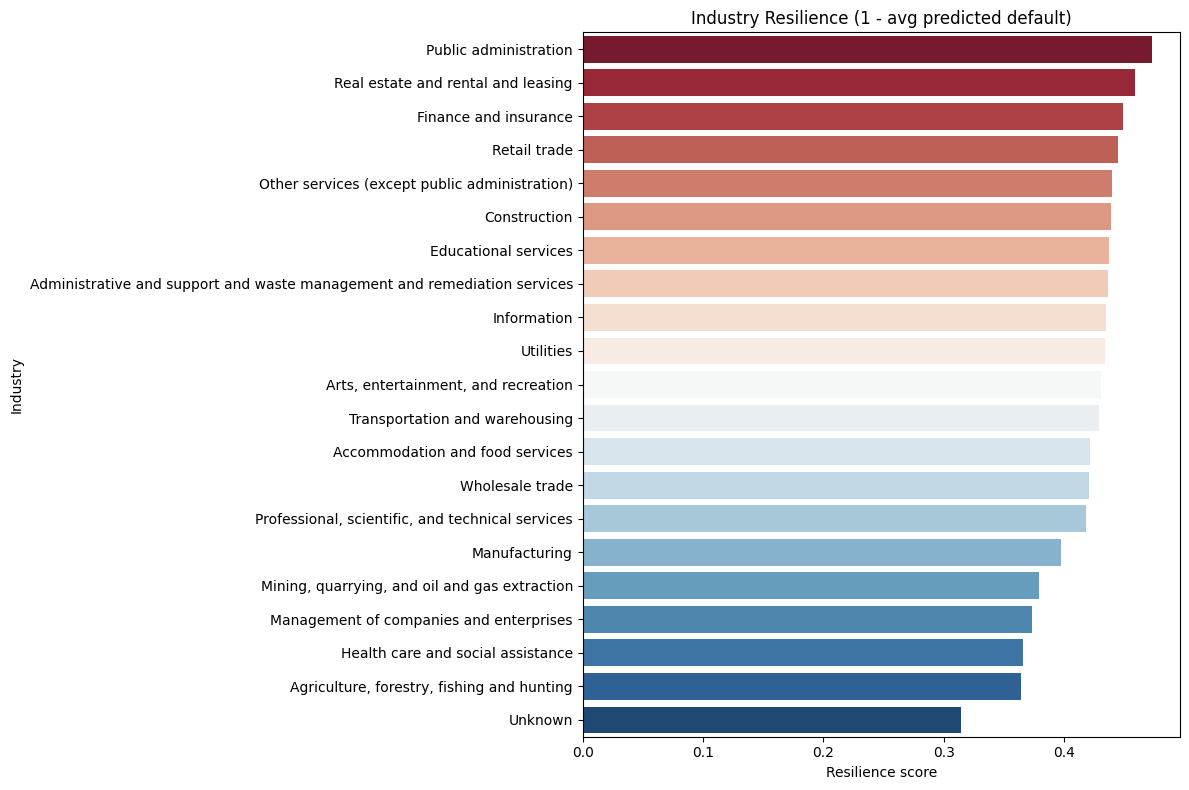

In [32]:
industry_col = "Industry"

industry_stats = (
    df.groupby(industry_col)
      .agg(
          n_loans=("actual_default", "size"),
          avg_pred_default=("pred_default_proba", "mean"),
          actual_default_rate=("actual_default", "mean")
      )
      .reset_index()
)

industry_stats["resilience_score"] = 1 - industry_stats["avg_pred_default"]

# Bar "heatmap" of industry resilience
plt.figure(figsize=(12, 8))
sns.barplot(
    data=industry_stats.sort_values("resilience_score", ascending=False),
    x="resilience_score",
    y=industry_col,
    palette="RdBu"
)
plt.title("Industry Resilience (1 - avg predicted default)")
plt.xlabel("Resilience score")
plt.ylabel("Industry")
plt.tight_layout()

fig.savefig(
    "industry_resilience.png",
    dpi=600,               
    bbox_inches="tight"   
)
plt.show()


In [35]:
zip_stats["Zip3"] = zip_stats["Zip"].astype(str).str[:3]

zip_stats = zip_stats[
    ~zip_stats["Zip3"].isin(["995", "996", "997", "998", "999", "967", "968"])
]
#removing AK / Hawaii for clarity of vis

In [36]:
import geopandas as gpd

zcta = gpd.read_file("shapedata/tl_2020_us_zcta510.shp")

zcta = zcta.rename(columns={"ZCTA5CE10": "ZIP"})
zcta["ZIP"] = zcta["ZIP"].astype(str).str.zfill(5)

zcta.head()


,ZIP,GEOID10,CLASSFP10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,43451,43451,B5,G6350,S,63484189,157689,+41.3183193,-083.6150363,"POLYGON ((-83.70873 41.32733, -83.70815 41.327..."
1,43452,43452,B5,G6350,S,121525288,13721740,+41.5202297,-082.9770334,"POLYGON ((-83.08698 41.5378, -83.08256 41.5377..."
2,43456,43456,B5,G6350,S,9320978,1003775,+41.6318300,-082.8393923,"MULTIPOLYGON (((-82.83558 41.71082, -82.83515 ..."
3,43457,43457,B5,G6350,S,48004678,0,+41.2673301,-083.4274872,"POLYGON ((-83.4965 41.25371, -83.48382 41.2537..."
4,43458,43458,B5,G6350,S,2573816,39915,+41.5304461,-083.2133648,"POLYGON ((-83.22229 41.53102, -83.22228 41.532..."


In [37]:
zip_map = zcta.merge(zip_stats, left_on="ZIP", right_on=zip_col, how="left")


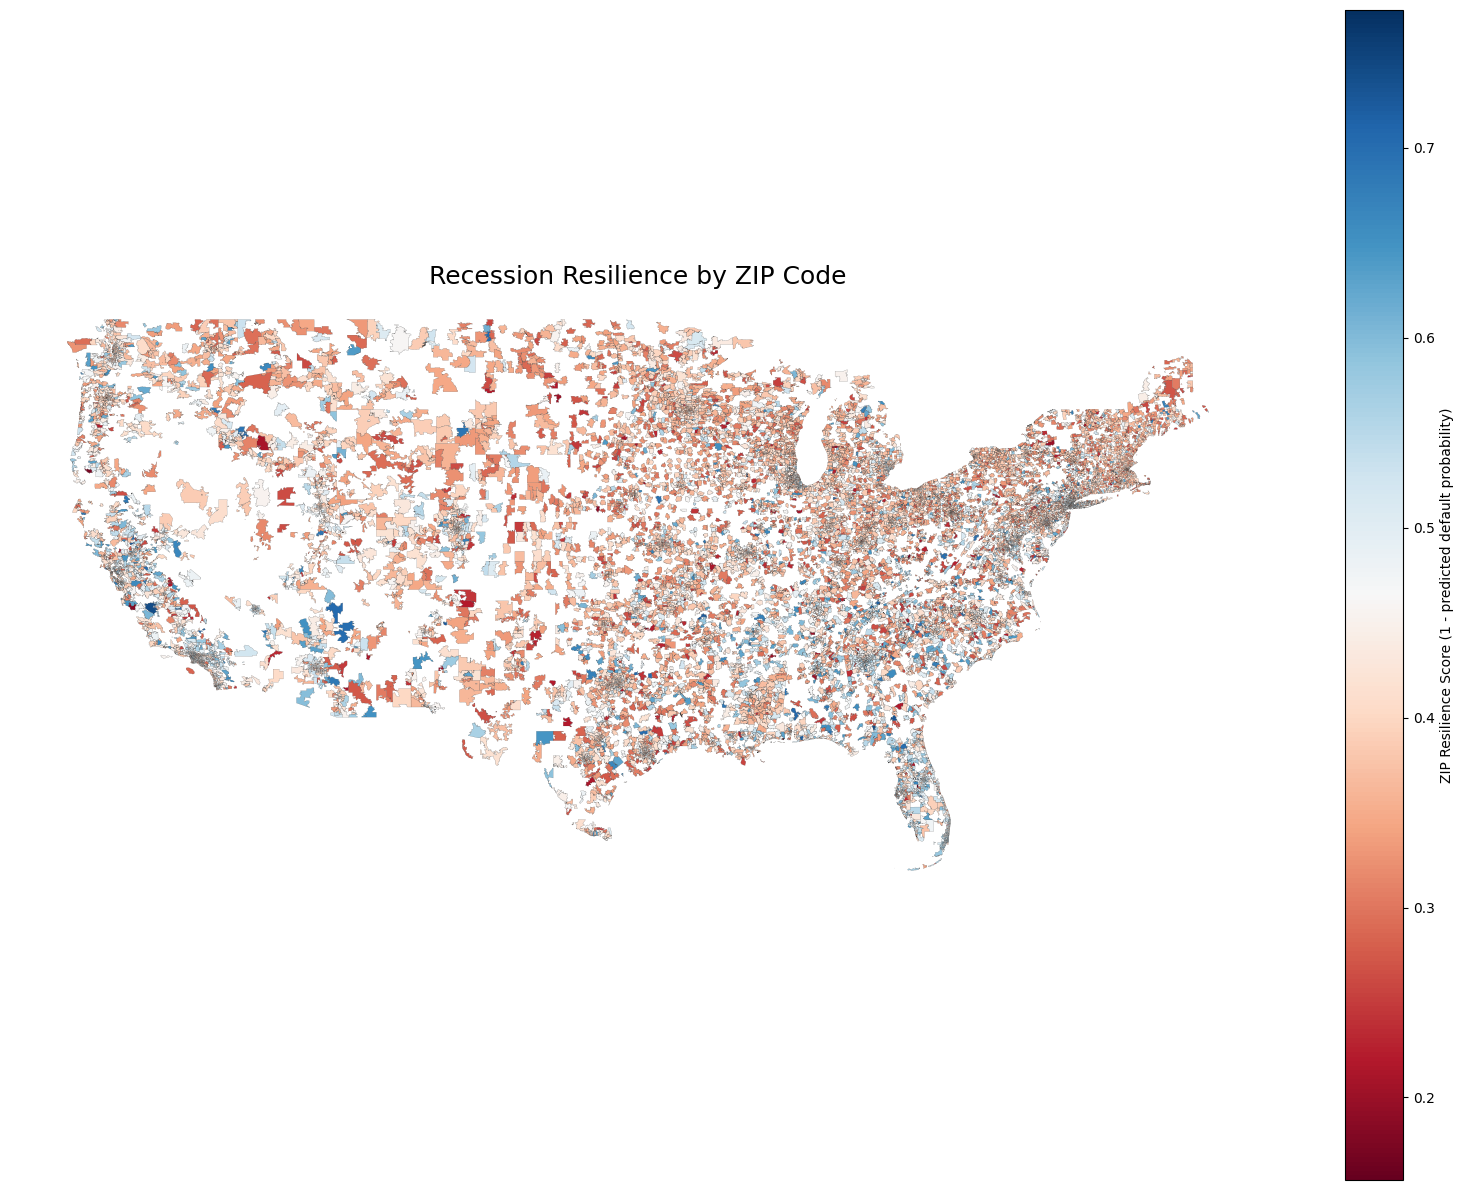

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(16, 12))

zip_map.plot(
    column="resilience_score",
    cmap="RdBu",
    linewidth=0.1,
    ax=ax,
    edgecolor="0.2",
    legend=True,
    legend_kwds={"label": "ZIP Resilience Score (1 - predicted default probability)"}
)

ax.set_title("Recession Resilience by ZIP Code", fontsize=18)
ax.axis("off")
plt.tight_layout()
fig.savefig(
    "zip_heatmap_highres.png",
    dpi=600,               # 300 dpi is print quality; you can go 400–600 if needed
    bbox_inches="tight"    # trims extra whitespace
)
plt.show()
